In [1]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:13<00:00, 158MB/s]

Dataset ready!


In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from google.colab import files
uploaded = files.upload()  # select best_model.pth from your laptop
import os
os.makedirs("model", exist_ok=True)
torch.save(torch.load("best_model.pth"), "model/best_model.pth")
print("Model ready at model/best_model.pth!")

Using device: cuda


Saving best_model.pth to best_model (1).pth
Model ready at model/best_model.pth!


In [4]:
base_path = "plantvillage/plantvillage dataset/color"

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(base_path)
class_names  = full_dataset.classes   # save this — needed for labels
total        = len(full_dataset)
train_size   = int(0.8 * total)
val_size     = total - train_size

torch.manual_seed(42)
train_indices, val_indices = torch.utils.data.random_split(
    range(total), [train_size, val_size]
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(base_path, transform=val_transform),
    val_indices.indices
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Val images: {len(val_dataset)}")
print(f"Classes: {len(class_names)}")

Val images: 10861
Classes: 38


In [5]:
model = efficientnet_b0(weights=None)   # no pretrained weights — we load our own
model.classifier[1] = nn.Linear(in_features=1280, out_features=38)

model.load_state_dict(torch.load("model/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("best_model.pth loaded successfully!")
print("This is the 99.56% model from day11.")

best_model.pth loaded successfully!
This is the 99.56% model from day11.


In [6]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

correct = (all_preds == all_labels).sum()
total   = len(all_labels)
print(f"Val images evaluated: {total}")
print(f"Correct: {correct} | Wrong: {total - correct}")
print(f"Accuracy: {100. * correct / total:.2f}%")

Val images evaluated: 10861
Correct: 10824 | Wrong: 37
Accuracy: 99.66%


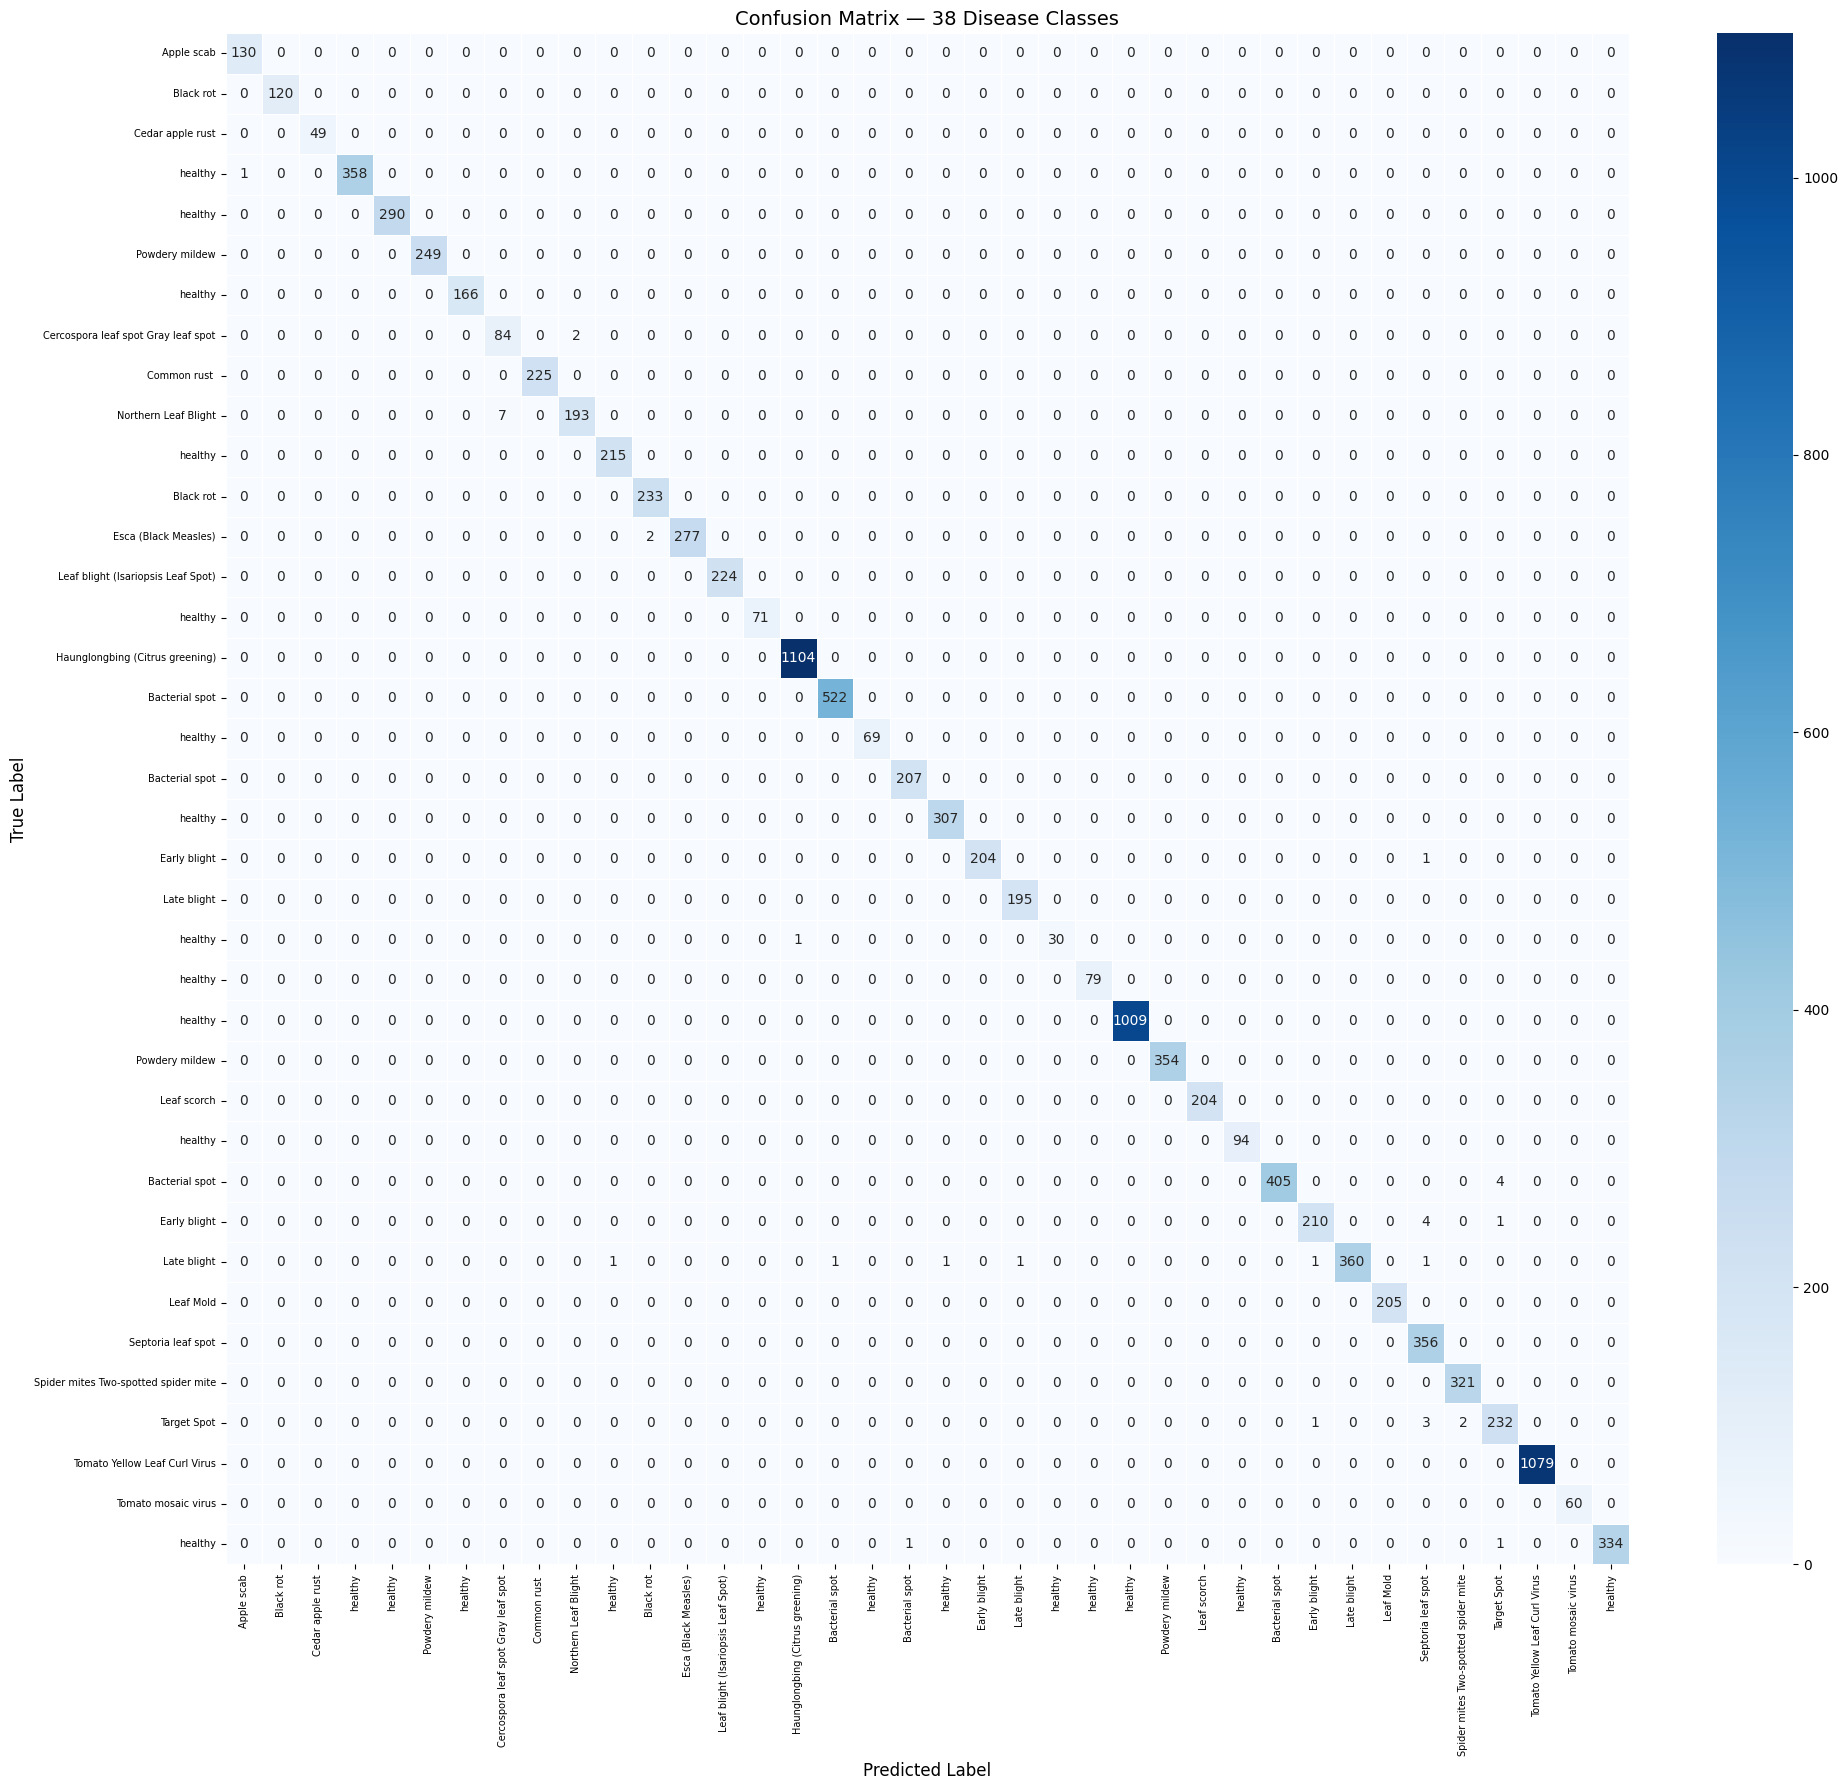

Saved as confusion_matrix.png


In [7]:
cm = confusion_matrix(all_labels, all_preds)

# Clean class names for display (remove Plant___ prefix)
short_names = [c.split("___")[1].replace("_", " ") for c in class_names]

plt.figure(figsize=(20, 18))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=short_names,
            yticklabels=short_names,
            linewidths=0.5)

plt.title("Confusion Matrix — 38 Disease Classes", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Saved as confusion_matrix.png")

In [8]:
# Zero out the diagonal (correct predictions) — we only want errors
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Find top 10 most confused pairs
error_indices = np.dstack(np.unravel_index(
    np.argsort(cm_errors.ravel())[::-1], cm_errors.shape
))[0][:10]

print("Top 10 most confused disease pairs:")
print(f"{'True Label':<40} {'Predicted As':<40} {'Count':>5}")
print("-" * 87)

for true_idx, pred_idx in error_indices:
    count = cm_errors[true_idx][pred_idx]
    if count == 0:
        break
    true_name = short_names[true_idx]
    pred_name = short_names[pred_idx]
    print(f"{true_name:<40} {pred_name:<40} {count:>5}")

Top 10 most confused disease pairs:
True Label                               Predicted As                             Count
---------------------------------------------------------------------------------------
Northern Leaf Blight                     Cercospora leaf spot Gray leaf spot          7
Early blight                             Septoria leaf spot                           4
Bacterial spot                           Target Spot                                  4
Target Spot                              Septoria leaf spot                           3
Esca (Black Measles)                     Black rot                                    2
Cercospora leaf spot Gray leaf spot      Northern Leaf Blight                         2
Target Spot                              Spider mites Two-spotted spider mite         2
Late blight                              Early blight                                 1
healthy                                  Bacterial spot                             

In [9]:
print("Per-class accuracy (worst performers first):\n")
print(f"{'Disease':<45} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 75)

class_acc = []
for i, name in enumerate(short_names):
    mask    = all_labels == i
    total_i = mask.sum()
    correct_i = (all_preds[mask] == i).sum()
    acc = 100. * correct_i / total_i if total_i > 0 else 0
    class_acc.append((acc, name, correct_i, total_i))

# Sort by accuracy ascending — worst first
for acc, name, correct_i, total_i in sorted(class_acc):
    marker = " ←" if acc < 97 else ""
    print(f"{name:<45} {correct_i:>8} {total_i:>8} {acc:>9.1f}%{marker}")

Per-class accuracy (worst performers first):

Disease                                        Correct    Total   Accuracy
---------------------------------------------------------------------------
Northern Leaf Blight                               193      200      96.5% ←
healthy                                             30       31      96.8% ←
Target Spot                                        232      238      97.5%
Cercospora leaf spot Gray leaf spot                 84       86      97.7%
Early blight                                       210      215      97.7%
Late blight                                        360      366      98.4%
Bacterial spot                                     405      409      99.0%
Esca (Black Measles)                               277      279      99.3%
healthy                                            334      336      99.4%
Early blight                                       204      205      99.5%
healthy                                          